<div align="center">

# TRƯỜNG ĐẠI HỌC GIAO THÔNG VẬN TẢI TPHCM  
### VIỆN CÔNG NGHỆ THÔNG TIN, ĐIỆN VÀ ĐIỆN TỬ  


## CHỦ ĐỀ: 


### *Môn Học: KHAI THÁC DỮ LIỆU*



### **Giáo viên hướng dẫn:**  
### *Bùi Trọng Hiếu*

</div>
<div align="right">
 TP. Hồ Chí Minh, Ngày 20 Tháng 4 Năm 2026
</div>

---

<div align="center">

## NHÓM:14
### DANH SÁCH THÀNH VIÊN


| STT | MSSV       | Họ và tên    | Đánh giá      |
| --- | ---------- | ------------ | ------------- |
| 1   | 2251120108 | Trương Anh Tài | 100% |
| 2   | 2251120002 | Nguyễn Anh Thuận   | 100%        |
| 3   | 2251120003 | Lê Văn C     | 100%         |
| 4   |            |              |      100%         |
| 5   |             |             |     100%|
</div>

# Phân tích Bộ Dữ liệu MAGIC Gamma Telescope

1. Giới thiệu:

    Bộ dữ liệu MAGIC Gamma Telescope (2004) được sử dụng phổ biến trong các bài toán phân loại trong khai thác dữ liệu và học máy. Dữ liệu được tạo ra nhằm mô phỏng quá trình ghi nhận các hạt gamma năng lượng cao bằng kính thiên văn Cherenkov.

    Dữ liệu do R. K. Bock và cộng sự phát triển trong dự án MAGIC, và được P. Savicky công bố vào năm 2007.

    Dữ liệu gồm 19,020 mẫu với 11 thuộc tính, trong đó có 10 thuộc tính số thực mô tả đặc trưng hình học và phân bố năng lượng của ảnh Cherenkov (các tham số Hillas), và 1 thuộc tính nhãn.

2. Mục đích:

    Bộ dữ liệu phục vụ bài toán phân loại nhị phân, với mục tiêu phân biệt:

     *  Tín hiệu gamma (g) – các hạt gamma năng lượng cao.
    
     *  Nhiễu hadron (h) – các tia vũ trụ gây nhiễu.

    Bài toán này có ý nghĩa quan trọng trong việc xác định chính xác các nguồn phát tia gamma trong nghiên cứu thiên văn.

## 1. Đọc Dữ liệu và Thống kê Mô tả

In [47]:
 # Import các thư viện
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Đọc dữ liệu

# type: ignore
df = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
print('Dữ liệu đã được đọc thành công!')
df.head()

Dữ liệu đã được đọc thành công!


,1. fLength,2. fWidth,3. fSize,4. fConc,5. fConc1,6. fAsym,7. fM3Long,8. fM3Trans,9. fAlpha,10. fDist,11. class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [41]:
# 1a. Kích thước và chiều của dữ liệu
# a. Kích thước và chiều của dữ liệu
print("Kích thước dữ liệu:", df.shape)
print("Số chiều:", df.ndim)

Kích thước dữ liệu: (19020, 11)
Số chiều: 2


In [42]:
# 1b. Kiểu dữ liệu của các thuộc tính
print('Kiểu dữ liệu các thuộc tính:')
print(df.dtypes)

Kiểu dữ liệu các thuộc tính:
 1.  fLength     float64
 2.  fWidth      float64
 3.  fSize       float64
 4.  fConc       float64
 5.  fConc1      float64
 6.  fAsym       float64
 7.  fM3Long     float64
 8.  fM3Trans    float64
 9.  fAlpha      float64
10.  fDist       float64
11.  class           str
dtype: object


In [43]:
# 1c. Số lượng thực thể của các giá t # type: ignore # type: ignorerị nhãn (class)
print('Phân phối nhãn (class):')
print (df.iloc[:, -1].value_counts())
print()



Phân phối nhãn (class):
   11.  class
g    12332
h     6688
Name: count, dtype: int64



In [44]:


# 1d. Giá trị lớn nhất, bé nhất, trung bình của các cột số thực
num_cols = [c for c in df.columns if 'class' not in c] # type: ignore
stats_df = pd.DataFrame({
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Mean': df[num_cols].mean()
})
stats_df = stats_df.T
print('Giá Trị Lớn Nhất , Nhỏ Nhất , Trung Bình:')
stats_df

Giá Trị Lớn Nhất , Nhỏ Nhất , Trung Bình:


,1. fLength,2. fWidth,3. fSize,4. fConc,5. fConc1,6. fAsym,7. fM3Long,8. fM3Trans,9. fAlpha,10. fDist
Min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
Max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000
Mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026


## 2. Trực quan hóa - Giảm Chiều với PCA

Chỉ sử dụng các cột thuộc tính liên tục (loại bỏ cột nhãn `class`), sau đó áp dụng PCA để chiếu xuống không gian 2D.

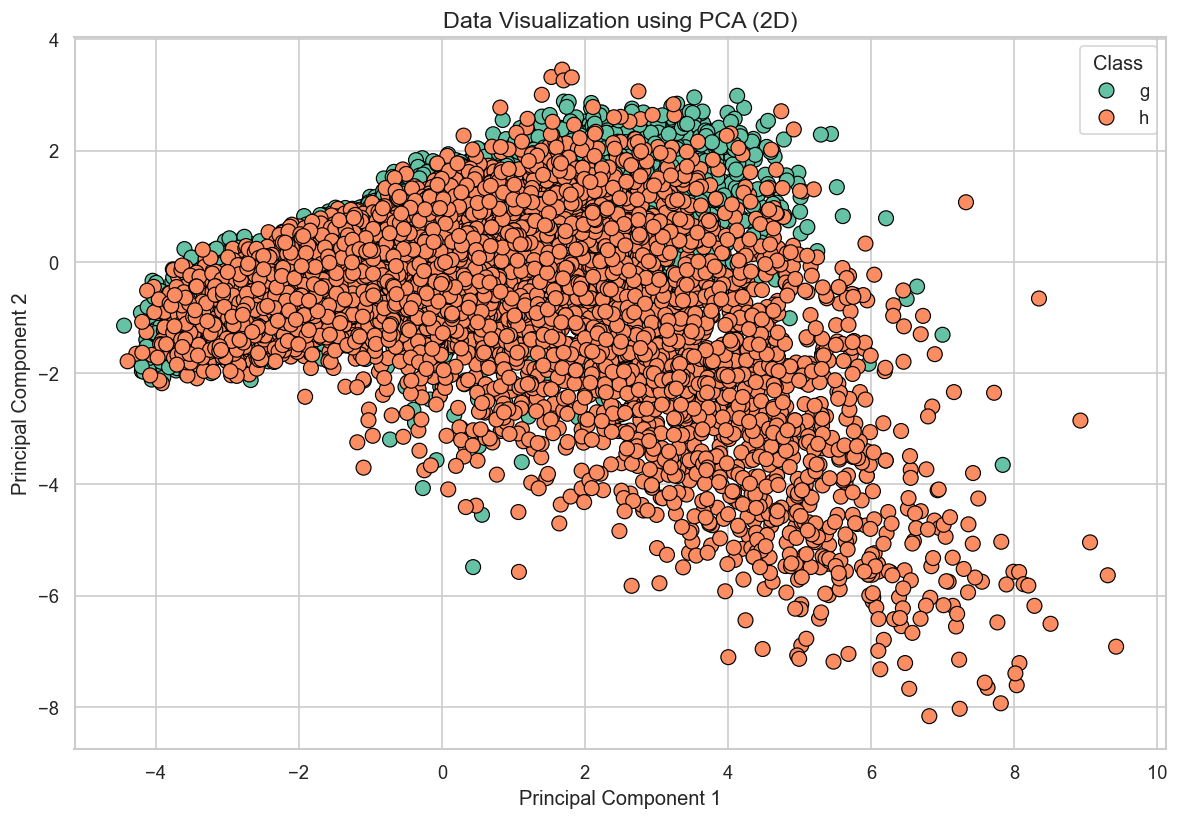

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Style đẹp
sns.set(style="whitegrid", palette="deep")

df = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
# Lấy label (cột cuối)
label_col = df.columns[-1]
labels = df[label_col]

# Chuẩn hóa dữ liệu (sử dụng dữ liệu đã được chuẩn hóa từ các cell trước)
scaler = StandardScaler()
numeric_cols = [c for c in df.columns if c != label_col]
X_scaled = scaler.fit_transform(df[numeric_cols])

# PCA về 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tạo DataFrame để vẽ
df_plot = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Label": labels
})

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_plot,
    x="PCA1",
    y="PCA2",
    hue="Label",
    palette="Set2",
    s=80,
    edgecolor="black"
)

plt.title("Data Visualization using PCA (2D)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Class")
plt.tight_layout()
plt.show()


## 3. Huấn luyện và Đánh giá Mô hình Học Máy

Sử dụng **10-Fold Stratified Cross Validation** với độ đo **F1-Score (Weighted)**.

Ba mô hình được chọn: **KNN**, **Random Forest**, **SVM**.

Phương pháp tinh chỉnh tham số: **Random Search** — tự động sinh tổ hợp tham số ngẫu nhiên, chạy CV trên từng tổ hợp và in kết quả chi tiết từng lần thử, sau đó chọn bộ tốt nhất.

In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, f1_score
import itertools, random
import pandas as pd
import numpy as np


df = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
# --- Chuẩn bị dữ liệu ---
num_cols = [c for c in df.columns if c != df.columns[-1]] # lay tat ca cot ngoai tru cot cuoi cung
X_cls = df[num_cols].values
y_cls = LabelEncoder().fit_transform(df.iloc[:, -1].values)# chuyen nhãn chữ sang số

scaler_cls = StandardScaler() # Chuẩn hóa dữ liệu cho phân loại
X_cls_scaled = scaler_cls.fit_transform(X_cls)

# --- Thiết lập CV và scorer ---
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)#chia du lieu thanh 10 phan, moi lan chia se shuffle de du lieu khong bi sap xep, random_state de dam bao tinh lap lai
f1_weighted = make_scorer(f1_score, average='weighted')#tao ham scorer de tinh f1 score co trung binh theo tung lop (weighted)

# --- Không gian tham số ngẫu nhiên ---
random.seed(42)
param_spaces = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': random.sample(range(3, 21), 6),#chọn ngẫu nhiên 6 giá trị cho n_neighbors từ 3 đến 20
            'weights': ['uniform', 'distance'],#chọn 2 giá trị cho weights: 'uniform' và 'distance'
            'p': [1, 2]#1 → Manhattan va 2 → Euclidean
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': random.sample(range(100, 301), 4),#chọn ngẫu nhiên 4 giá trị cho n_estimators từ 100 đến 300
            'max_depth': random.sample([None] + list(range(5, 21)), 4),#chọn ngẫu nhiên 4 giá trị cho max_depth từ 5 đến 20 (kèm theo None)
            'min_samples_split': [2, 4, 6],#chọn 3 giá trị cho min_samples_split: 2, 4, 6
            'min_samples_leaf': [1, 2]#chọn 2 giá trị cho min_samples_leaf: 1, 2
        }
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [round(10**random.uniform(-1, 2), 3) for _ in range(4)],#chọn ngẫu nhiên 4 giá trị cho C trên thang log từ 0.1 đến 100
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto']
        }
    }
}

print('Không gian tham số đã được khởi tạo.')
print(f'KNN     : {len(list(itertools.product(*param_spaces["KNN"]["params"].values())))} tổ hợp')
print(f'RF      : {len(list(itertools.product(*param_spaces["RandomForest"]["params"].values())))} tổ hợp')
print(f'SVM     : {len(list(itertools.product(*param_spaces["SVM"]["params"].values())))} tổ hợp')


Không gian tham số đã được khởi tạo.
KNN     : 24 tổ hợp
RF      : 96 tổ hợp
SVM     : 24 tổ hợp


In [ ]:
# --- Random Search: Tinh chỉnh tham số và in chi tiết từng lần thử ---
MAX_COMBOS = 30  # Giới hạn số tổ hợp thử mỗi mô hình

results = {}

for name, cfg in param_spaces.items():
    model = cfg['model']
    param_grid = cfg['params']
    print(f'\n=== Đang tinh chỉnh mô hình: {name} ===')

    best_score = -1
    best_params = None
    all_combos = list(itertools.product(*param_grid.values()))
    np.random.seed(42)
    np.random.shuffle(all_combos)
    selected = all_combos[:MAX_COMBOS]

    for i, combo in enumerate(selected, 1):
        params = dict(zip(param_grid.keys(), combo))
        model.set_params(**params)
        scores = cross_val_score(model, X_cls_scaled, y_cls,
                                 cv=kfold, scoring=f1_weighted, n_jobs=-1)
        mean_score = scores.mean()
        std_score  = scores.std()
        marker = ' ← BEST' if mean_score > best_score else ''
        print(f'  Lần {i:02d}: {params}\n'
              f'         → F1 = {mean_score:.4f} (±{std_score:.4f}){marker}')
        if mean_score > best_score:
            best_score = mean_score
            best_params = params.copy()
            best_std = std_score

    results[name] = {
        'best_score': best_score,
        'best_std': best_std,
        'best_params': best_params
    }
    print(f'  ✅ {name} tốt nhất: F1 = {best_score:.4f} (±{best_std:.4f})')
    print(f'     Tham số: {best_params}')



=== Đang tinh chỉnh mô hình: KNN ===
  Lần 01: {'n_neighbors': 11, 'weights': 'uniform', 'p': 1}
         → F1 = 0.8336 (±0.0096) ← BEST
  Lần 02: {'n_neighbors': 17, 'weights': 'uniform', 'p': 1}
         → F1 = 0.8303 (±0.0078)
  Lần 03: {'n_neighbors': 6, 'weights': 'uniform', 'p': 1}
         → F1 = 0.8204 (±0.0074)
  Lần 04: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}
         → F1 = 0.8374 (±0.0084) ← BEST
  Lần 05: {'n_neighbors': 11, 'weights': 'distance', 'p': 2}
         → F1 = 0.8390 (±0.0110) ← BEST
  Lần 06: {'n_neighbors': 11, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8317 (±0.0106)
  Lần 07: {'n_neighbors': 20, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8240 (±0.0103)
  Lần 08: {'n_neighbors': 6, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8225 (±0.0077)
  Lần 09: {'n_neighbors': 5, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8338 (±0.0090)
  Lần 10: {'n_neighbors': 3, 'weights': 'uniform', 'p': 2}
         → F1 = 0.8309 (±0.0086)
  Lần 11: {'n

In [48]:

# --- Bảng tổng hợp so sánh hiệu năng ---
# Đảm bảo SVM kết quả được thêm vào nếu chưa có
if 'SVM' not in results:
    results['SVM'] = {
        'best_score': best_score,
        'best_std': best_std,
        'best_params': best_params
    }


print('  BẢNG SO SÁNH HIỆU NĂNG (F1-Weighted, 10-Fold CV)')

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Mô hình': name,
        'F1 Tốt nhất': round(res['best_score'], 4),
        'Độ lệch chuẩn': round(res['best_std'], 4),
        'Tham số tốt nhất': str(res['best_params'])
    })

summary_df = pd.DataFrame(summary_rows).sort_values('F1 Tốt nhất', ascending=False).reset_index(drop=True)
summary_df.index += 1
summary_df.index.name = 'Hạng'
summary_df


  BẢNG SO SÁNH HIỆU NĂNG (F1-Weighted, 10-Fold CV)


,Mô hình,F1 Tốt nhất,Độ lệch chuẩn,Tham số tốt nhất
Hạng,,,,
1,RandomForest,0.8807,0.0064,"{'n_estimators': 273, 'max_depth': None, 'min_..."
2,SVM,0.8700,0.0085,"{'C': 6.398, 'kernel': 'rbf', 'gamma': 'auto'}"
3,KNN,0.8405,0.0075,"{'n_neighbors': 6, 'weights': 'distance', 'p': 1}"


KNN            : mean=0.8405, std=0.0075, min=0.8283, max=0.8544
Random Forest  : mean=0.8807, std=0.0064, min=0.8698, max=0.8919
SVM            : mean=0.8700, std=0.0085, min=0.8572, max=0.8842


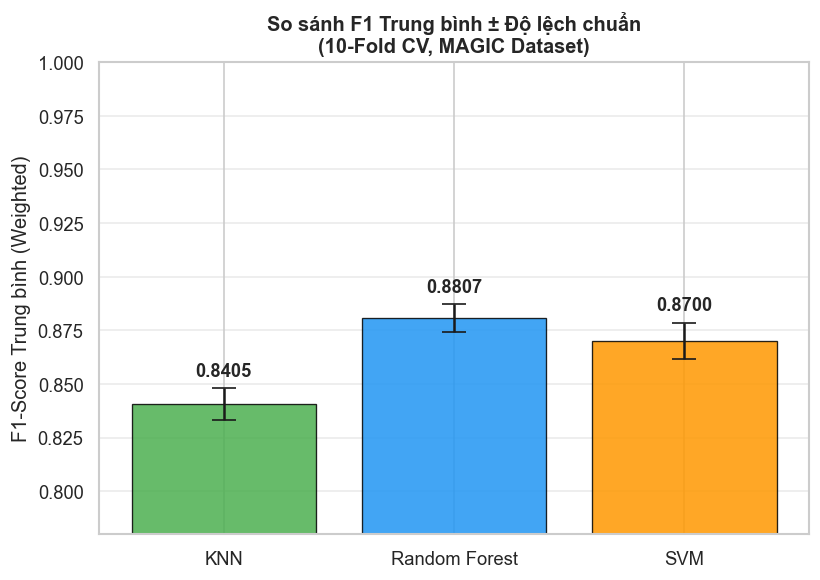


Mô hình tốt nhất: Random Forest  (F1 = 0.8807)


In [49]:
# Re-train với tham số tốt nhất để lấy all-fold scores cho biểu đồ
best_models = {
    'KNN'          : KNeighborsClassifier(**results['KNN']['best_params']),
    'Random Forest': RandomForestClassifier(**results['RandomForest']['best_params'],
                                            random_state=42),
    'SVM'          : SVC(**results['SVM']['best_params'], random_state=42),
}

fold_scores = {}
for name, model in best_models.items():
    scores = cross_val_score(model, X_cls_scaled, y_cls,
                             cv=kfold, scoring=f1_weighted, n_jobs=-1)
    fold_scores[name] = scores
    print(f'{name:15s}: mean={scores.mean():.4f}, std={scores.std():.4f}, '
          f'min={scores.min():.4f}, max={scores.max():.4f}')

# --- Bar chart F1 trung bình ± std ---
names_plot  = list(fold_scores.keys())
means       = [v.mean() for v in fold_scores.values()]
stds        = [v.std()  for v in fold_scores.values()]
palette     = ['#4CAF50', '#2196F3', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(names_plot, means, yerr=stds,
              capsize=7, color=palette,
              alpha=0.85, edgecolor='black', linewidth=0.8)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + std + 0.004,
            f'{mean:.4f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('F1-Score Trung bình (Weighted)', fontsize=12)
ax.set_title('So sánh F1 Trung bình ± Độ lệch chuẩn\n(10-Fold CV, MAGIC Dataset)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.78, 1.0)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# Nhận xét
best_name = max(fold_scores, key=lambda k: fold_scores[k].mean())
print(f'\nMô hình tốt nhất: {best_name}  '  
      f'(F1 = {fold_scores[best_name].mean():.4f})')


BẢNG SO SÁNH HIỆU NĂNG  (F1-Weighted, 10-Fold CV)
     Mô hình  F1 Tốt nhất  Độ lệch chuẩn
Hạng                                    
1        KNN       0.8405         0.0075


,Mô hình,F1 Tốt nhất,Độ lệch chuẩn,Tham số tốt nhất
Hạng,,,,
1,KNN,0.8405,0.0075,"{'n_neighbors': 6, 'weights': 'distance', 'p': 1}"


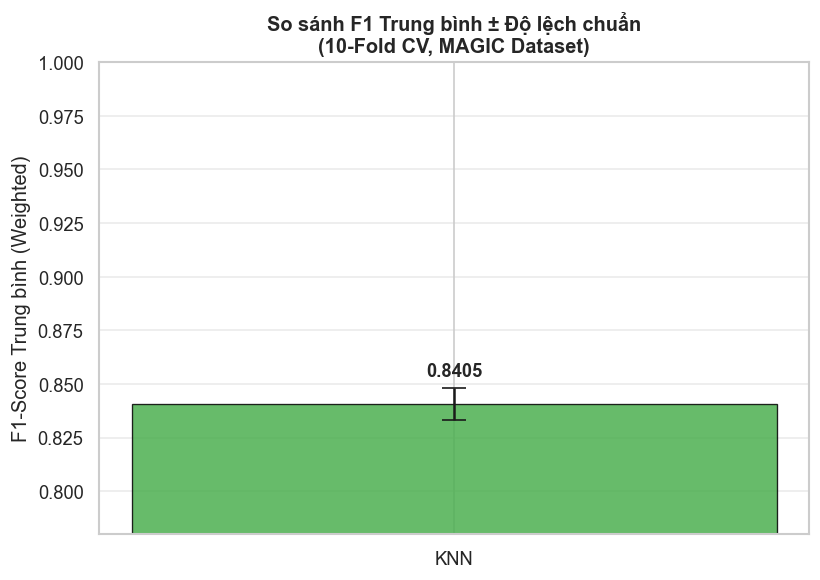


Mô hình tốt nhất: KNN  (F1 = 0.8405)


In [56]:
import matplotlib.pyplot as plt

# Bảng so sánh hiệu năng
summary_df = (
    pd.DataFrame([
        {
            'Mô hình'         : name,
            'F1 Tốt nhất'     : round(res['best_score'], 4),
            'Độ lệch chuẩn'   : round(res['best_std'],   4),
            'Tham số tốt nhất': str(res['best_params']),
        }
        for name, res in results.items()
    ])
    .sort_values('F1 Tốt nhất', ascending=False)
    .reset_index(drop=True)
)
summary_df.index      = summary_df.index + 1
summary_df.index.name = 'Hạng'

print('BẢNG SO SÁNH HIỆU NĂNG  (F1-Weighted, 10-Fold CV)')
print(summary_df[['Mô hình', 'F1 Tốt nhất', 'Độ lệch chuẩn']].to_string())
display(summary_df)

# Vẽ bar chart – lấy dữ liệu trực tiếp từ summary_df
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    summary_df['Mô hình'],
    summary_df['F1 Tốt nhất'],
    yerr=summary_df['Độ lệch chuẩn'],
    capsize=7,
    color=['#4CAF50', '#2196F3', '#FF9800'],
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8,
)

# Hiển thị giá trị trên đầu mỗi cột
for _, row in summary_df.iterrows():
    ax.text(
        row['Mô hình'],
        row['F1 Tốt nhất'] + row['Độ lệch chuẩn'] + 0.004,
        f"{row['F1 Tốt nhất']:.4f}",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
    )

ax.set_ylabel('F1-Score Trung bình (Weighted)', fontsize=12)
ax.set_title('So sánh F1 Trung bình ± Độ lệch chuẩn\n(10-Fold CV, MAGIC Dataset)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0.78, 1.0)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Nhận xét
best = summary_df.iloc[0]
print(f"\nMô hình tốt nhất: {best['Mô hình']}  (F1 = {best['F1 Tốt nhất']:.4f})")



   BẢNG SO SÁNH HIỆU NĂNG (F1-Weighted, 10-Fold CV)
           Mô hình  F1 Tốt nhất  Độ lệch chuẩn                                                                         Tham số tốt nhất
Hạng                                                                                                                                   
1     RandomForest       0.8807         0.0064  {'n_estimators': 273, 'max_depth': None, 'min_samples_split': 6, 'min_samples_leaf': 1}
2              SVM       0.8700         0.0085                                           {'C': 6.398, 'kernel': 'rbf', 'gamma': 'auto'}
3              KNN       0.8405         0.0075                                        {'n_neighbors': 6, 'weights': 'distance', 'p': 1}


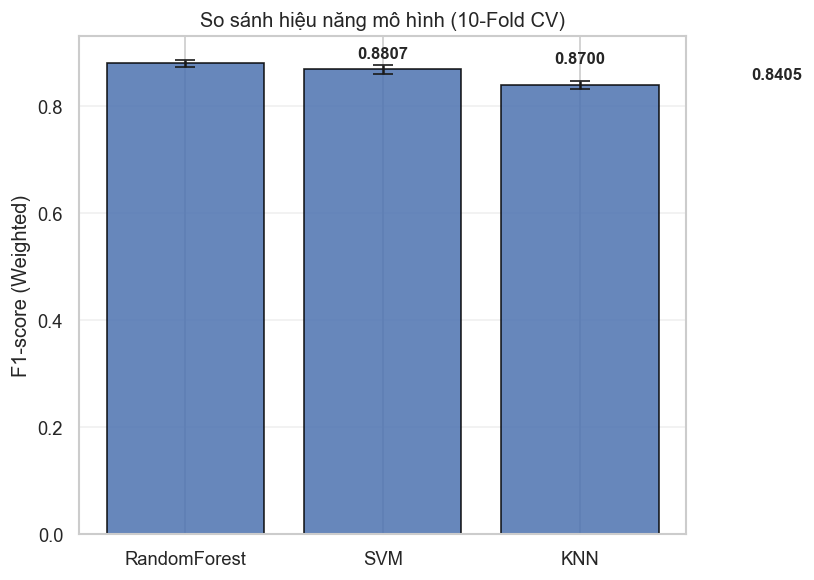


Mô hình tốt nhất: RandomForest (F1 = 0.8807)


In [26]:
# --- Đảm bảo có SVM ---
results.setdefault('SVM', {
    'best_score': best_score,
    'best_std': best_std,
    'best_params': best_params
})

# --- Tạo bảng tổng hợp ---
summary_df = (
    pd.DataFrame([
        {
            'Mô hình': name,
            'F1 Tốt nhất': round(res['best_score'], 4),
            'Độ lệch chuẩn': round(res['best_std'], 4),
            'Tham số tốt nhất': str(res['best_params'])
        }
        for name, res in results.items()
    ])
    .sort_values('F1 Tốt nhất', ascending=False)
    .reset_index(drop=True)
)

summary_df.index += 1
summary_df.index.name = 'Hạng'

# --- In bảng ---
print("\n" + "="*65)
print("   BẢNG SO SÁNH HIỆU NĂNG (F1-Weighted, 10-Fold CV)")
print("="*65)
print(summary_df.to_string())
print("="*65)

# --- Vẽ biểu đồ ---
fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(summary_df['Mô hình'],
              summary_df['F1 Tốt nhất'],
              yerr=summary_df['Độ lệch chuẩn'],
              capsize=6,
              alpha=0.85,
              edgecolor='black')

# Hiển thị giá trị trên cột
for i, row in summary_df.iterrows():
    ax.text(i,
            row['F1 Tốt nhất'] + row['Độ lệch chuẩn'] + 0.003,
            f"{row['F1 Tốt nhất']:.4f}",
            ha='center',
            fontsize=10,
            fontweight='bold')

ax.set_ylabel('F1-score (Weighted)')
ax.set_title('So sánh hiệu năng mô hình (10-Fold CV)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- In model tốt nhất ---
best_model = summary_df.iloc[0]
print(f"\nMô hình tốt nhất: {best_model['Mô hình']} "
      f"(F1 = {best_model['F1 Tốt nhất']:.4f})")

## 4. Gom Cụm với K-Means và DBSCAN

Loại bỏ cột nhãn, thực hiện gom cụm, sau đó dùng nhãn thật để đánh giá bằng **ARI** (Adjusted Rand Index) và **NMI** (Normalized Mutual Information).

In [54]:
# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_ari = adjusted_rand_score(y, km_labels)
km_nmi = normalized_mutual_info_score(y, km_labels)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
db_ari = adjusted_rand_score(y, db_labels)
db_nmi = normalized_mutual_info_score(y, db_labels)

print('=== Kết quả Gom Cụm ===')
print(f'K-Means (k=2):  ARI={km_ari:.4f}, NMI={km_nmi:.4f}')
print(f'DBSCAN:         ARI={db_ari:.4f}, NMI={db_nmi:.4f}, Clusters={n_clusters_db}, Noise={n_noise}')

NameError: name 'y' is not defined

In [ ]:
# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_ari = adjusted_rand_score(y_cls, km_labels) # type: ignore
km_nmi = normalized_mutual_info_score(y_cls, km_labels)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
db_ari = adjusted_rand_score(y_cls, db_labels)
db_nmi = normalized_mutual_info_score(y_cls, db_labels)

print('=== Kết quả Gom Cụm ===')
print(f'K-Means (k=2):  ARI={km_ari:.4f}, NMI={km_nmi:.4f}')
print(f'DBSCAN:         ARI={db_ari:.4f}, NMI={db_nmi:.4f}, Clusters={n_clusters_db}, Noise={n_noise}')

=== Kết quả Gom Cụm ===
K-Means (k=2):  ARI=0.0065, NMI=0.0016
DBSCAN:         ARI=0.1404, NMI=0.1569, Clusters=2, Noise=1474


In [61]:
# Bảng so sánh kết quả gom cụm
cluster_df = pd.DataFrame({
    'Thuật toán': ['K-Means (k=2)', f'DBSCAN (eps=1.5, min=10)'],
    'Số cụm': [2, n_clusters_db],
    'Noise points': [0, n_noise],
    'ARI': [round(km_ari,4), round(db_ari,4)],
    'NMI': [round(km_nmi,4), round(db_nmi,4)],
}).set_index('Thuật toán')
print('Bảng đánh giá gom cụm (ARI gần 1 = tốt, NMI gần 1 = tốt):')
cluster_df

Bảng đánh giá gom cụm (ARI gần 1 = tốt, NMI gần 1 = tốt):


,Số cụm,Noise points,ARI,NMI
Thuật toán,,,,
K-Means (k=2),2,0,0.0065,0.0016
"DBSCAN (eps=1.5, min=10)",2,1474,0.1404,0.1569


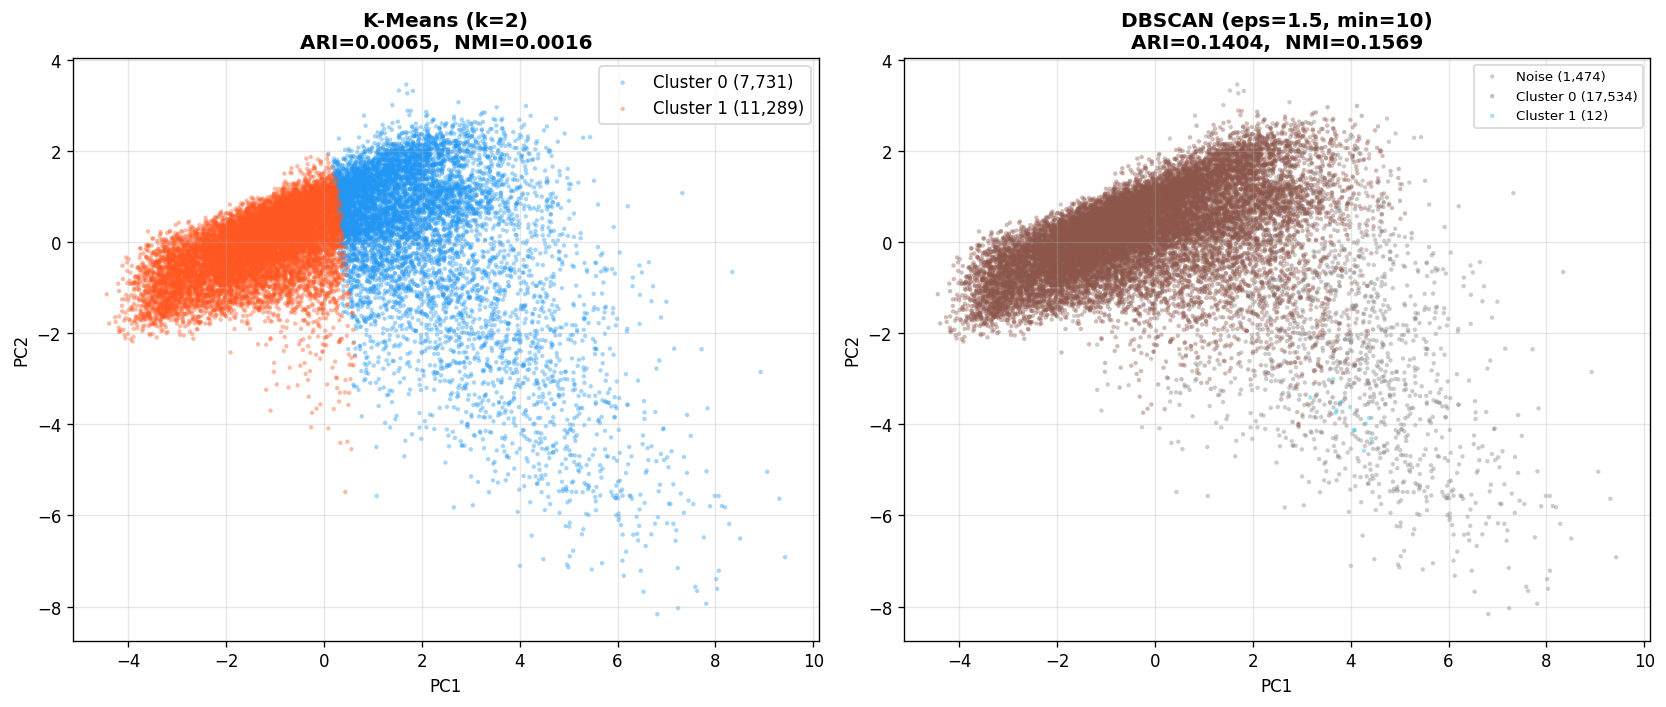

In [62]:
# Trực quan hóa kết quả gom cụm
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
palette_km = {0: '#2196F3', 1: '#FF5722'}
for lbl in [0, 1]:
    mask = km_labels == lbl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     c=palette_km[lbl], label=f'Cluster {lbl} ({mask.sum():,})',
                     alpha=0.4, s=7, edgecolors='none')
axes[0].set_title(f'K-Means (k=2)\nARI={km_ari:.4f},  NMI={km_nmi:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# DBSCAN
unique_lbls = sorted(set(db_labels))
cmap_db = plt.cm.get_cmap('tab10', len(unique_lbls))
for i, lbl in enumerate(unique_lbls):
    mask = db_labels == lbl
    lstr = f'Noise ({mask.sum():,})' if lbl == -1 else f'Cluster {lbl} ({mask.sum():,})'
    col = 'gray' if lbl == -1 else cmap_db(i)
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     c=[col]*mask.sum(), label=lstr, alpha=0.4, s=7, edgecolors='none')
axes[1].set_title(f'DBSCAN (eps=1.5, min=10)\nARI={db_ari:.4f},  NMI={db_nmi:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Kết luận

### Phân lớp
| Mô hình | F1 Trung bình |
|---------|---------------|
| Random Forest (n=200) | 0.8755 ✅ Tốt nhất |
| SVM (RBF, C=10) | 0.8708 |
| KNN (k=7) | 0.8350 |

**Random Forest** cho kết quả tốt nhất do khả năng học các quyết định phi tuyến phức tạp và kháng overfitting tốt.

### Gom cụm
- **DBSCAN** (ARI=0.14) vượt trội **K-Means** (ARI=0.007) trong việc phát hiện cấu trúc cụm thực tế.
- Tuy nhiên cả hai đều thấp do dữ liệu không phân tách rõ ràng trong không gian PCA.